# Project 4: Phosphorylation–dephosphorylation

MCSB Bootcamp — Mathematical and Computational Track

Jun Allard

## Background and Part I

Many proteins are activated (phosphorylated) by enzymes called kinases,
and deactivated (dephosphorylated) by enzymes called phosphatases.
Intuitively, the fraction of active protein is determined by the balance
of kinases to phosphatases. This balance is maintained by constant
activation and inactivation in what is called a *futile cycle*.

a.  Sketch a diagram where the horizontal axis is the ratio of kinase to
    phosphatase (say, in log scale), and the vertical axis is the
    fraction of activated protein in steady state. Use your intuition to
    sketch what you think the curve should look like.

# S curve (or reverse S curve)

In mathematics, we call this plot a bifurcation diagram (the steady
state as a function of a parameter). In biology, we call this particular
plot a dose-response curve (how the output of a system responds to the
dose of an input).

## Model statement

To activate the protein, the kinase must first bind to the inactive
form, then catalyze activation. It may also unbind before it has a
chance to catalyze. The same is true for the phosphatase. There are
therefore 6 species of molecule. Let $[A]$ be the concentration of A,
$[AP]$ be the concentration of the AP complex, and so on. We have
defined six populations, with concentrations:

$$\begin{aligned}
{}[A] &  & &\text{unbound active protein}\\
[I] &  & &\text{unbound inactive protein}\\
[AP] &  & &\text{complex of active protein and phosphatase}\\
[P] &= [P_\mathrm{tot}] - [AP] & &\text{unbound phosphatase}\\
[IK] &  & &\text{complex of inactive protein and kinase}\\
[K] &= [K_\mathrm{tot}] - [IK] & &\text{unbound kinase}
\end{aligned}$$

Assume the total concentration of phosphatase $[P_\mathrm{tot}]$ and
kinase $[K_\mathrm{tot}]$ are constant. Therefore, we do not need to
track the concentration of P, since it is determined by
$[P_\mathrm{tot}]$ and $[AP]$. Similarly for K. Therefore, there are 4
concentrations to keep track of.

There are 6 chemical reactions, shown below.

$$\mathrm{I} + \mathrm{K}
\;\underset{k^I_\mathrm{off}}{\overset{k^I_\mathrm{on}}{\rightleftharpoons}}\;
\mathrm{IK}
\;\xrightarrow{\;k^A_\mathrm{cat}\;}\;
\mathrm{A} + \mathrm{K}$$

$$\mathrm{A} + \mathrm{P}
\;\underset{k^A_\mathrm{off}}{\overset{k^A_\mathrm{on}}{\rightleftharpoons}}\;
\mathrm{AP}
\;\xrightarrow{\;k^I_\mathrm{cat}\;}\;
\mathrm{I} + \mathrm{P}$$

Let’s assume reactions are proportional to the concentration of the
reactants, so $\mathrm{A}+\mathrm{P} \rightarrow \mathrm{AP}$ occurs at
rate
$k^A_\mathrm{on} [P] [A] = k^A_\mathrm{on} ([P_\mathrm{tot}] - [AP]) [A]$.
Therefore, we have defined 6 rate parameters:

$$\begin{aligned}
k^A_\mathrm{on} &= 10 \ \mathrm{s}^{-1}\mu\mathrm{M}^{-1} & \qquad k^I_\mathrm{on} &= 10 \ \mathrm{s}^{-1}\mu\mathrm{M}^{-1}\\
k^A_\mathrm{off} &= 10 \ \mathrm{s}^{-1} & \qquad k^I_\mathrm{off} &= 10 \ \mathrm{s}^{-1}\\
k^A_\mathrm{cat} &= 100 \ \mathrm{s}^{-1} & \qquad k^I_\mathrm{cat} &= 10 \ \mathrm{s}^{-1}
\end{aligned}$$

## Part II

b.  Write down 4 ODEs describing the populations of A, I, AP and IK. The
    first two equations are

$$\begin{aligned}
\frac{d[A]}{dt} &= -k^A_\mathrm{on} \left( [P_\mathrm{tot}] - [AP]\right) [A] + k^A_\mathrm{off} [AP] + k^A_\mathrm{cat} [IK],\\
\frac{d[AP]}{dt} &= +k^A_\mathrm{on} \left( [P_\mathrm{tot}] - [AP]\right) [A] - k^A_\mathrm{off} [AP] - k^I_\mathrm{cat} [AP].
\end{aligned}$$

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# rate of change of active protein
dA/dt = -k_a_on * (P_tot - AP) * A + k_a_off * AP + k_a_cat * IK

# rate of change of active protein bound to phosphotase
dAP/dt = k_a_on * (P_tot - AP) * A - k_a_off * AP - k_i_cat * AP

# rate of change of inactivate protein
dI/dt = -k_i_on * (K_tot - IK) * I + k_i_off * IK + k_a_cat * AP

# rate of change of inactive protein bound to kinase
dIK/dt = k_i_on * (K_tot - IK) * I - k_i_off * IK - k_i_cat * IK

c.  Assume that at time $t=0$, all of the protein is in the inactive,
    unbound state, and that its concentration is
    $I_\mathrm{tot}=1~\mu\mathrm{M}$. What are the appropriate initial
    conditions for the ODEs?

t = 0

I = 1
A = 0
AP = 0
IK = 0


d.  Write code to simulate this ODE system to steady state. Use the
    parameters stated above, the initial conditions from the previous
    question, and $I_\mathrm{tot}=1~\mu\mathrm{M}$,
    $K_\mathrm{tot}=1~\mu\mathrm{M}$ and
    $P_\mathrm{tot}=1~\mu\mathrm{M}$.

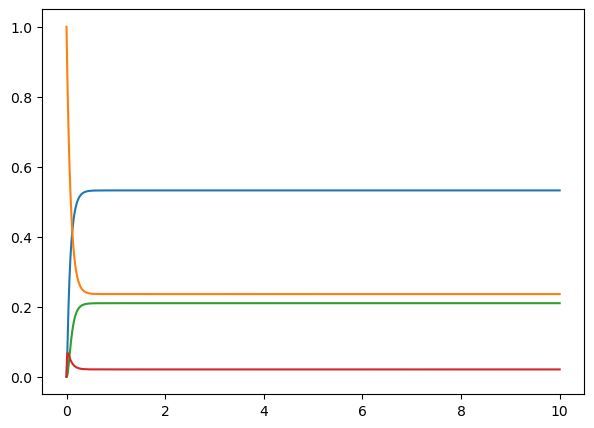

In [39]:
from matplotlib._api import deprecation
from matplotlib._api import deprecation
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# define rate of change in multivarate state
def multirate(t, state, P_tot, K_tot):
    A, I, AP, IK = state

    P = P_tot - AP
    K = K_tot - IK

    k_a_on = 10
    k_i_on = 10
    k_a_off = 10
    k_i_off = 10
    k_a_cat = 100
    k_i_cat = 10


    dA = -k_a_on * P * A + k_a_off * AP + k_a_cat * IK     # rate of change of active protein
    dAP = k_a_on * P * A - k_a_off * AP - k_i_cat * AP     # rate of change of active protein bound to phosphotase
    dI = -k_i_on * K * I + k_i_off * IK + k_i_cat * AP    # rate of change of inactivate protein
    dIK = k_i_on * K * I - k_i_off * IK - k_a_cat * IK    # rate of change of inactive protein bound to kinase
    

    return [dA, dI, dAP, dIK]

# define initial conditions
A = 0
AP = 0
I = 1
IK = 0
P = 1
K_tot = 1
P_tot = 1


t_span = [0, 10]
sol = solve_ivp(multirate, t_span, [A, I, AP, IK], args=(P_tot, K_tot), t_eval=np.linspace(0, 10, 1000))

T = sol.t
plt.figure(figsize=(7,5))

plt.plot(T, sol.y[0], label='A')
plt.plot(T, sol.y[1], label='I')
plt.plot(T, sol.y[2], label='AP')
plt.plot(T, sol.y[3], label='IK')

# fig, ax = plt.subplots()

## Part III

e.  Do a parameter sweep in $K_\mathrm{tot}$, logarithmic from
    $K_\mathrm{tot} = 10^{-3}~\mu\mathrm{M}$ to
    $K_\mathrm{tot} = 10^{+2}~\mu\mathrm{M}$. Plot the total amount of
    activated protein in steady state as a function of $K_\mathrm{tot}$
    (with a log axis in $K_\mathrm{tot}$). Does the plot match the
    intuitive sketch you made in question (a)?

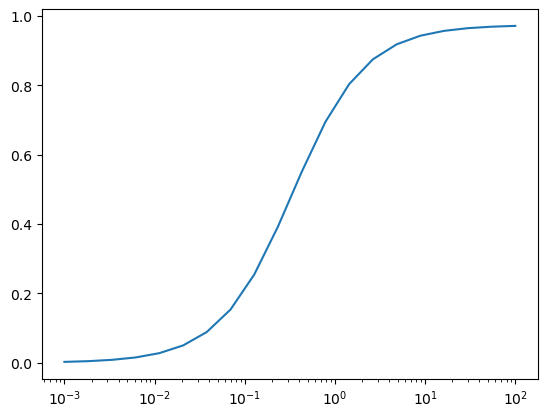

In [56]:
import numpy as np

# define initial conditions
A = 0
AP = 0
I = 1
IK = 0
P = 1
# K_tot defined below
P_tot = 1

K_range = np.logspace(-3, 2, num=20)

activated = []
for K_tot in K_range:
    t_span = [0, 10]
    sol = solve_ivp(multirate, t_span, [A, I, AP, IK], args=(P_tot, K_tot), t_eval=np.linspace(0, 10, 1000))

    T = sol.t

    A_ss = sol.y[0, -1]
    AP_ss = sol.y[2, -1]

    A_AP = A_ss + AP_ss
    activated.append(A_AP)


plt.plot(K_range, activated, label='A')
plt.xscale('log')


f.  Now do the same parameter sweep in $K_\mathrm{tot}$, identical to
    the previous question except $I_\mathrm{tot}=100~\mu\mathrm{M}$.
    What changed? In what circumstances might a cell gain an advantage
    from this kind of dose-response curve (compared to the previous
    question with $I_\mathrm{tot}=1~\mu\mathrm{M}$)? In what
    circumstances might a cell be disadvantaged by a dose-response curve
    like this (compared to the previous question with
    $I_\mathrm{tot}=1~\mu\mathrm{M}$)?[1]

[1] This type of behavior in systems biology is called
*ultrasensitivity*. This particular type of ultrasensitivity is called
*Goldbeter-Koshland ultrasensitivity*.

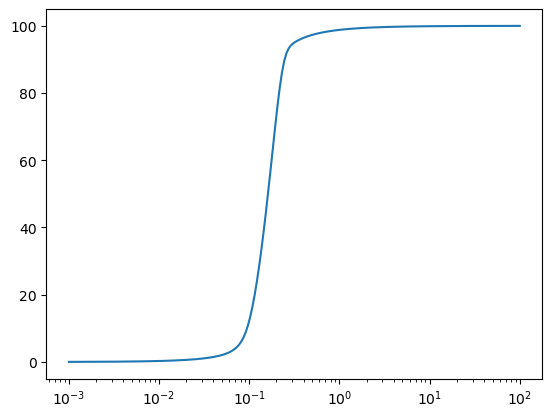

In [59]:
import numpy as np

# define initial conditions
A = 0
AP = 0
I = 100
IK = 0
P = 1
# K_tot defined below
P_tot = 1

K_range = np.logspace(-3, 2, num=200)

activated = []
for K_tot in K_range:
    t_span = [0, 10]
    sol = solve_ivp(multirate, t_span, [A, I, AP, IK], args=(P_tot, K_tot), t_eval=np.linspace(0, 10, 1000))

    T = sol.t

    A_ss = sol.y[0, -1]
    AP_ss = sol.y[2, -1]

    A_AP = A_ss + AP_ss
    activated.append(A_AP)


plt.plot(K_range, activated, label='A')
plt.xscale('log')
